# Oasis Infobyte – Task 1: Retail Sales Data Analysis

## Objective
Analyze retail/e-commerce transaction data to understand **sales trends, customer demographics, product performance, relationships between numerical variables, and actionable business insights**.

### Dataset
- **10,000 transactions**
- **22 columns**
- **Period:** January–December 2025
- **Currency:** Indian Rupees (INR)

### Task 1 checklist
- [x] Initial inspection: shape, data types and null-value check
- [x] Descriptive statistics: mean, median, mode and standard deviation
- [x] Monthly and quarterly sales trends
- [x] Customer age-group and gender analysis
- [x] Top 10 best-selling products
- [x] Revenue by product category
- [x] Correlation heatmap
- [x] Additional visualization revealing a non-obvious insight
- [x] Written observations after each chart
- [x] At least 3 actionable business recommendations


## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

file_path = "Oasis_Infobyte_Task_1_Retail_Sales_10000.csv"
df = pd.read_csv(file_path, parse_dates=["Order_Date"])

print("Dataset loaded successfully.")
display(df.head())


Dataset loaded successfully.


,Order_ID,Order_Date,Customer_ID,Customer_Age,Age_Group,Gender,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price_INR,Discount,Sales_INR,Cost_INR,Profit_INR,Payment_Method,City,State,Customer_Segment,Rating,Returned
0,ORD10447,2025-01-01,CUST0748,18,18-24,Female,P020,Jeans,Fashion,Clothing,2,"1,939.54",0.15,"3,297.22","2,240.00","1,057.22",UPI,Lucknow,Uttar Pradesh,Young Adult,5.00,No
1,ORD10649,2025-01-01,CUST0981,27,25-34,Female,P016,Water Bottle,Home & Office,Kitchen,1,584.69,0.05,555.46,310.00,245.46,UPI,Kanpur,Uttar Pradesh,Adult,4.50,No
2,ORD10678,2025-01-01,CUST1085,44,35-44,Male,P006,Wireless Earbuds,Electronics,Audio,2,"2,298.90",0.10,"4,138.02","2,760.00","1,378.02",UPI,Ongole,Andhra Pradesh,Middle Age,4.50,No
3,ORD10756,2025-01-01,CUST1532,26,25-34,Female,P022,Sunglasses,Fashion,Accessories,5,"1,270.13",0.10,"5,715.59","3,250.00","2,465.59",Credit Card,New Delhi,Delhi,Adult,4.50,No
4,ORD10849,2025-01-01,CUST0277,37,35-44,Male,P017,Coffee Mug,Home & Office,Kitchen,1,348.50,0.15,296.22,160.00,136.22,UPI,Varanasi,Uttar Pradesh,Middle Age,5.00,No


## 2. Initial Inspection: Shape, Data Types and Null Values

In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Data Types:")
display(df.dtypes.to_frame("Data Type"))

null_check = pd.DataFrame({
    "Null_Count": df.isnull().sum(),
    "Null_Percentage": (df.isnull().mean() * 100).round(2)
})
display(null_check)

print("Total missing values:", int(df.isnull().sum().sum()))


Rows: 10000
Columns: 22

Column Data Types:


,Data Type
Order_ID,object
Order_Date,datetime64[ns]
Customer_ID,object
Customer_Age,int64
Age_Group,object
Gender,object
Product_ID,object
Product_Name,object
Category,object
Sub_Category,object


,Null_Count,Null_Percentage
Order_ID,0,0.00
Order_Date,0,0.00
Customer_ID,0,0.00
Customer_Age,0,0.00
Age_Group,0,0.00
Gender,0,0.00
Product_ID,0,0.00
Product_Name,0,0.00
Category,0,0.00
Sub_Category,0,0.00


Total missing values: 0


### Observation
The dataset contains **10,000 rows and 22 columns**. The null-value check shows **0 missing values**, so no imputation is required before analysis. The date column is loaded as a datetime field, while categorical fields remain suitable for grouping and visualization.

## 3. Descriptive Statistics

In [3]:
numerical_columns = df.select_dtypes(include=np.number).columns

descriptive_stats = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Mode": df[numerical_columns].mode().iloc[0],
    "Standard Deviation": df[numerical_columns].std()
})

descriptive_stats


,Mean,Median,Mode,Standard Deviation
Customer_Age,31.49,31.00,18.00,9.16
Quantity,1.85,1.00,1.00,1.07
Unit_Price_INR,"2,446.12","1,533.11",390.66,"3,505.28"
Discount,0.09,0.10,0.10,0.07
Sales_INR,"4,173.43","1,880.91",351.59,"7,514.80"
Cost_INR,"3,052.51","1,160.00","1,120.00","6,366.04"
Profit_INR,"1,120.92",693.27,159.74,"1,422.09"
Rating,4.26,4.50,4.50,0.55


### Observation
The descriptive statistics establish the typical customer, order and financial values before visualization. Sales and profit show substantial variation because the dataset contains both low-priced stationery products and higher-value electronics, furniture and appliances. Ratings are concentrated toward the positive end of the scale.

## 4. Time Series Analysis – Monthly Sales Trend

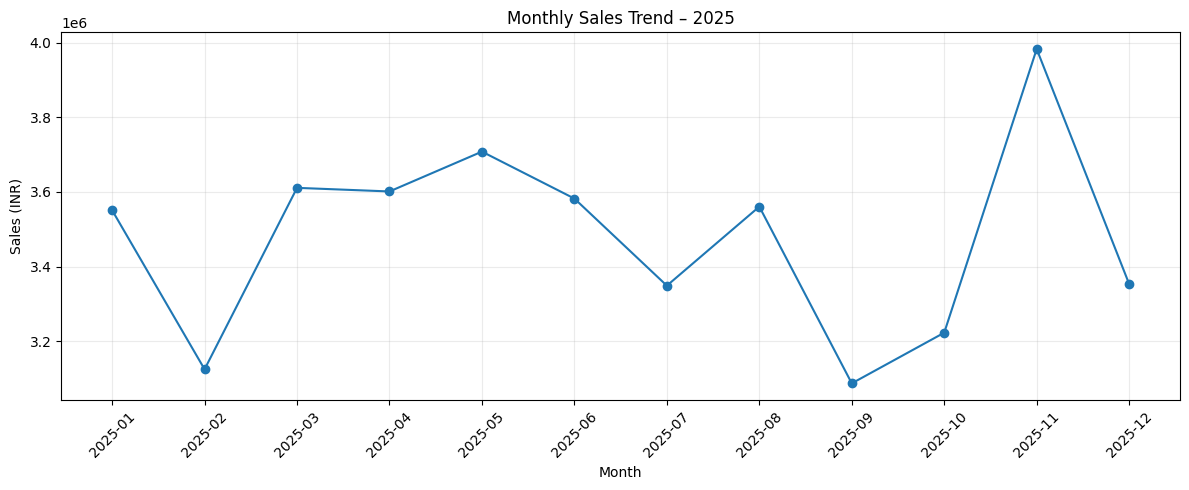

Highest-sales month: 2025-11 (3,983,318.96 INR)
Lowest-sales month: 2025-09 (3,086,825.24 INR)


In [4]:
monthly_sales = df.groupby(df["Order_Date"].dt.to_period("M"))["Sales_INR"].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend – 2025")
plt.xlabel("Month")
plt.ylabel("Sales (INR)")
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Highest-sales month:", monthly_sales.idxmax(), f"({monthly_sales.max():,.2f} INR)")
print("Lowest-sales month:", monthly_sales.idxmin(), f"({monthly_sales.min():,.2f} INR)")


### Observation
Monthly sales fluctuate throughout the year. **2025-11** is the strongest month at approximately **₹3,983,319**, while **2025-09** is the weakest at approximately **₹3,086,825**. The November spike is worth investigating for seasonal or promotional effects.

## 5. Time Series Analysis – Quarterly Sales Trend

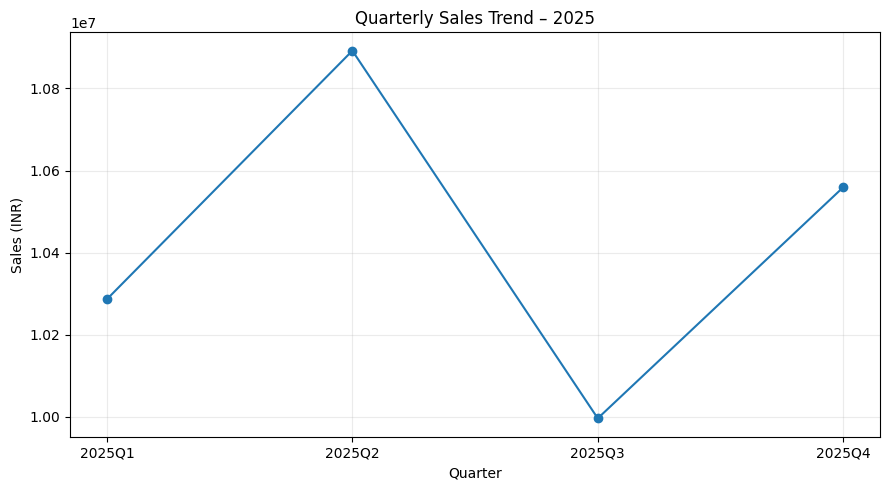

,Sales_INR
Order_Date,
2025Q1,"10,286,682.27"
2025Q2,"10,892,022.46"
2025Q3,"9,996,363.44"
2025Q4,"10,559,275.79"


In [5]:
quarterly_sales = df.groupby(df["Order_Date"].dt.to_period("Q"))["Sales_INR"].sum()

plt.figure(figsize=(9, 5))
plt.plot(quarterly_sales.index.astype(str), quarterly_sales.values, marker="o")
plt.title("Quarterly Sales Trend – 2025")
plt.xlabel("Quarter")
plt.ylabel("Sales (INR)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(quarterly_sales.to_frame("Sales_INR"))


### Observation
Quarterly performance is relatively balanced. **2025Q2** is the strongest quarter with approximately **₹10,892,022**, while **2025Q3** is the weakest. The business therefore does not depend on one quarter alone for the majority of annual revenue.

## 6. Customer Demographics – Age Group Distribution

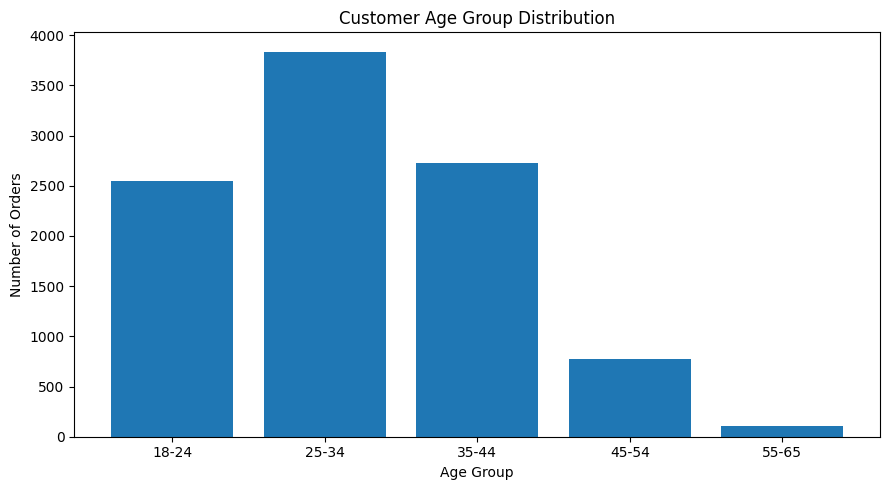

,Orders
Age_Group,
18-24,2546
25-34,3837
35-44,2728
45-54,779
55-65,110


In [6]:
age_counts = df["Age_Group"].value_counts().sort_index()

plt.figure(figsize=(9, 5))
plt.bar(age_counts.index, age_counts.values)
plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

display(age_counts.to_frame("Orders"))


### Observation
The **25-34** group is the largest, representing approximately **38.4% of orders**. Customers aged 18–44 account for the clear majority of transactions, so marketing and product bundles should prioritize these segments.

## 7. Customer Demographics – Gender Breakdown

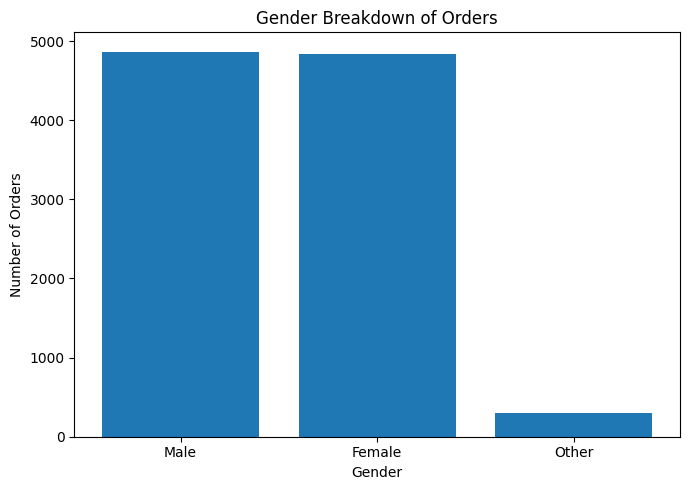

,Orders
Gender,
Male,4868
Female,4838
Other,294


In [7]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(gender_counts.index, gender_counts.values)
plt.title("Gender Breakdown of Orders")
plt.xlabel("Gender")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

display(gender_counts.to_frame("Orders"))


### Observation
The gender distribution is almost balanced between **Male (4,868)** and **Female (4,838)** orders. This suggests that broad, product-focused marketing may be more appropriate than strongly gender-specific campaigns.

## 8. Product Analysis – Top 10 Best-Selling Products

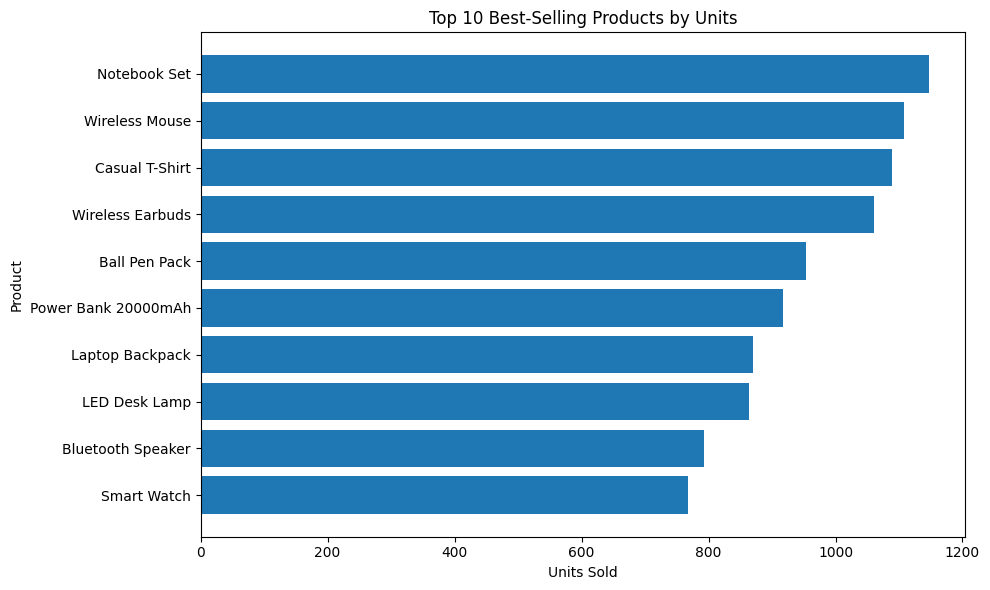

,Units_Sold,Revenue_INR
Product_Name,,
Notebook Set,1147,"414,885.11"
Wireless Mouse,1108,"703,752.01"
Casual T-Shirt,1089,"889,699.45"
Wireless Earbuds,1060,"2,218,428.89"
Ball Pen Pack,954,"171,479.65"
Power Bank 20000mAh,918,"1,327,753.04"
Laptop Backpack,870,"1,179,306.88"
LED Desk Lamp,863,"701,463.15"
Bluetooth Speaker,793,"1,302,148.69"


In [8]:
top10_products = (
    df.groupby("Product_Name")
      .agg(Units_Sold=("Quantity", "sum"), Revenue_INR=("Sales_INR", "sum"))
      .sort_values("Units_Sold", ascending=False)
      .head(10)
      .sort_values("Units_Sold")
)

plt.figure(figsize=(10, 6))
plt.barh(top10_products.index, top10_products["Units_Sold"])
plt.title("Top 10 Best-Selling Products by Units")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

display(top10_products.sort_values("Units_Sold", ascending=False))


### Observation
**Notebook Set** is the best-selling product by volume with **1,147 units sold**. Several lower-priced products rank highly by quantity, demonstrating that sales volume and revenue are not necessarily the same. Inventory decisions should consider both units and financial contribution.

## 9. Product Analysis – Revenue by Product Category

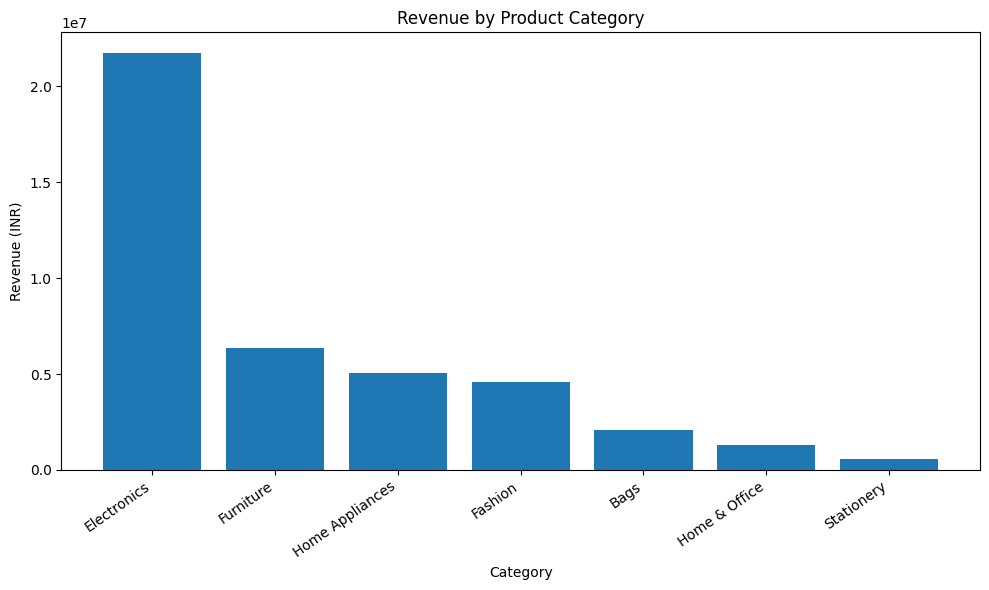

,Revenue_INR
Category,
Electronics,"21,736,235.16"
Furniture,"6,372,904.07"
Home Appliances,"5,059,117.34"
Fashion,"4,604,766.51"
Bags,"2,087,656.89"
Home & Office,"1,287,299.23"
Stationery,"586,364.76"


In [9]:
category_revenue = df.groupby("Category")["Sales_INR"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(category_revenue.index, category_revenue.values)
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

display(category_revenue.to_frame("Revenue_INR"))


### Observation
**Electronics** is the leading revenue category, generating approximately **₹21,736,235**, or **52.1% of total revenue**. It should receive strong inventory and supplier planning, while smaller categories can be evaluated for targeted growth opportunities.

## 10. Correlation Heatmap – Numerical Variables

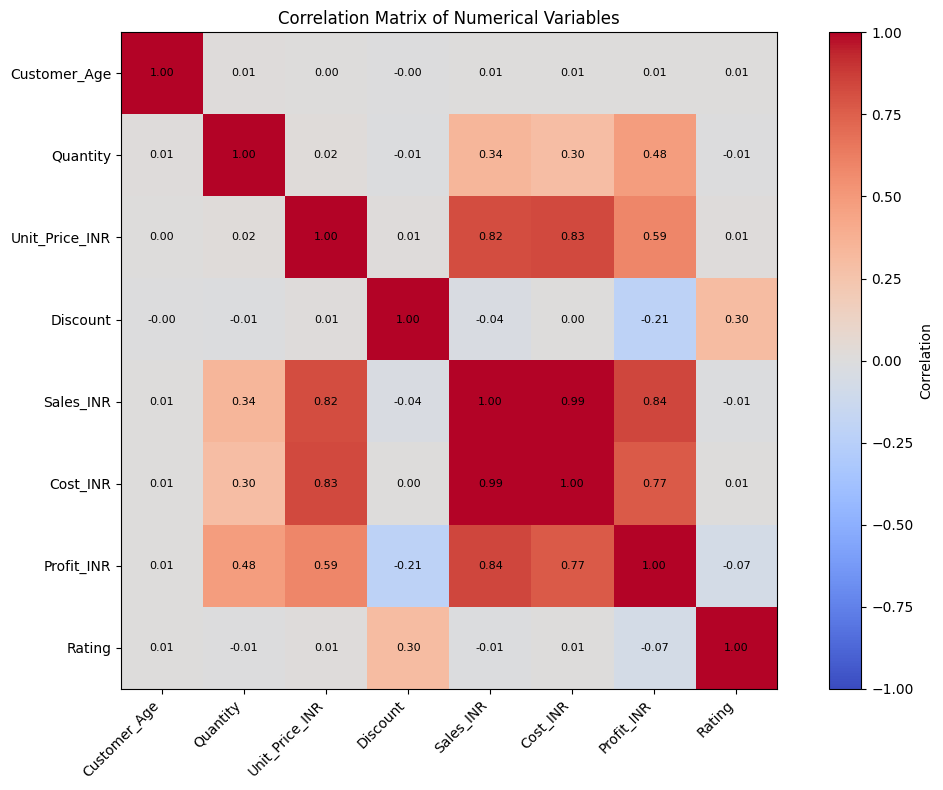

,Customer_Age,Quantity,Unit_Price_INR,Discount,Sales_INR,Cost_INR,Profit_INR,Rating
Customer_Age,1.00,0.01,0.00,-0.00,0.01,0.01,0.01,0.01
Quantity,0.01,1.00,0.02,-0.01,0.34,0.30,0.48,-0.01
Unit_Price_INR,0.00,0.02,1.00,0.01,0.82,0.83,0.59,0.01
Discount,-0.00,-0.01,0.01,1.00,-0.04,0.00,-0.21,0.30
Sales_INR,0.01,0.34,0.82,-0.04,1.00,0.99,0.84,-0.01
Cost_INR,0.01,0.30,0.83,0.00,0.99,1.00,0.77,0.01
Profit_INR,0.01,0.48,0.59,-0.21,0.84,0.77,1.00,-0.07
Rating,0.01,-0.01,0.01,0.30,-0.01,0.01,-0.07,1.00


In [10]:
numerical_data = df.select_dtypes(include=np.number)
corr_matrix = numerical_data.corr()

fig, ax = plt.subplots(figsize=(11, 8))
image = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8)

ax.set_title("Correlation Matrix of Numerical Variables")
fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

corr_matrix


### Observation
The heatmap shows strong relationships among **Quantity, Unit Price, Sales and Cost**, which is expected because these variables are directly connected to order value. Profit is also closely related to Sales and Cost. The negative Discount–Profit relationship is weaker than these direct financial relationships, but it provides a useful business question for further analysis.

## 11. Additional Visualization – Discount vs Average Profit

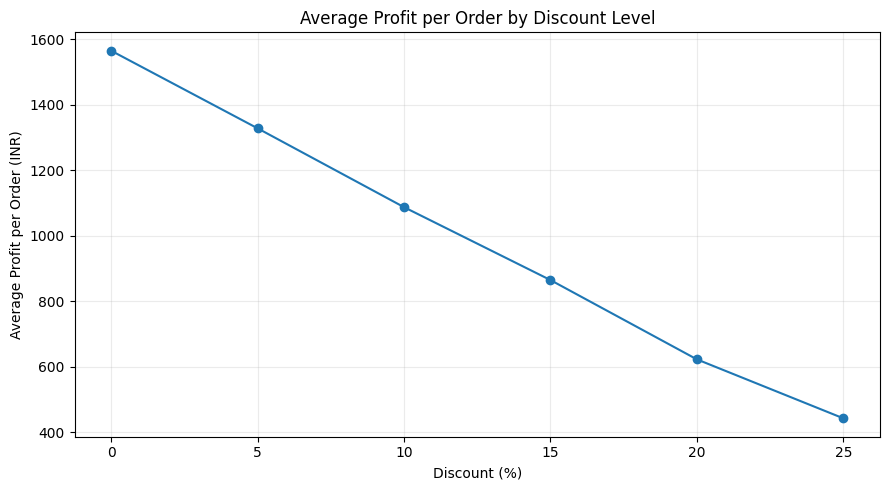

,Discount_Rate,Average_Profit_INR
0,0.00,"1,565.23"
1,0.05,"1,328.21"
2,0.10,"1,087.35"
3,0.15,864.67
4,0.20,622.43
5,0.25,442.38


In [11]:
discount_profit = df.groupby("Discount")["Profit_INR"].mean().reset_index()

plt.figure(figsize=(9, 5))
plt.plot(
    discount_profit["Discount"] * 100,
    discount_profit["Profit_INR"],
    marker="o"
)
plt.title("Average Profit per Order by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Average Profit per Order (INR)")
plt.xticks(discount_profit["Discount"] * 100)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(discount_profit.rename(columns={
    "Discount": "Discount_Rate",
    "Profit_INR": "Average_Profit_INR"
}))


### Non-Obvious Insight
Average profit per order falls as discounts increase: it decreases from approximately **₹1,565 with no discount** to approximately **₹442 at a 25% discount**. The Discount–Profit correlation is **-0.21**, which is negative.

The recommendation is not to eliminate discounts, but to make them **targeted and margin-aware** so that additional sales volume can justify the reduced margin.

## 12. Additional Business KPIs

In [12]:
total_sales = df["Sales_INR"].sum()
total_cost = df["Cost_INR"].sum()
total_profit = df["Profit_INR"].sum()
profit_margin = total_profit / total_sales * 100
return_rate = (df["Returned"] == "Yes").mean() * 100
avg_order_value = df["Sales_INR"].mean()

summary = pd.Series({
    "Total Sales (INR)": total_sales,
    "Total Cost (INR)": total_cost,
    "Total Profit (INR)": total_profit,
    "Overall Profit Margin (%)": profit_margin,
    "Average Order Value (INR)": avg_order_value,
    "Return Rate (%)": return_rate
})

summary


Total Sales (INR)           41,734,343.96
Total Cost (INR)            30,525,120.00
Total Profit (INR)          11,209,223.96
Overall Profit Margin (%)           26.86
Average Order Value (INR)        4,173.43
Return Rate (%)                      2.80
dtype: float64

### Observation
These KPIs provide a compact management view of revenue, cost, profitability, average order value and returns. They can also serve as the starting KPI set for a future Power BI dashboard.

## 13. Conclusion and Actionable Business Recommendations

### Key Findings
1. **Electronics is the main revenue driver**, contributing approximately **52.1% of total revenue**.
2. The **25-34 age group is the largest customer segment**, contributing approximately **38.4% of orders**.
3. **2025-11** is the strongest month, with a noticeable seasonal spike toward the end of the year.
4. **Notebook Set** leads the product ranking by units sold.
5. Higher discounts are associated with **lower average profit per order**.

### Actionable Recommendations

**1. Protect availability of high-revenue categories.**  
Prioritize inventory and supplier planning for **Electronics**, while using cross-selling to increase the value of orders containing high-volume products.

**2. Target the largest customer segment.**  
Design personalized campaigns and bundles for the **25-34** segment, while separately testing offers for other age groups.

**3. Use discounting selectively.**  
Set discount limits based on product margin. Use higher discounts only where the expected increase in sales volume can compensate for lower profit per order.

**4. Plan for seasonal peaks.**  
Use the monthly and quarterly trends to prepare inventory, marketing budgets and promotional campaigns before strong-demand periods.

**5. Measure products using volume, revenue and profit together.**  
The best-selling product by units is not automatically the most valuable product financially. Track all three measures before deciding which products to promote.

## 14. Final Task 1 Checklist

| Requirement | Status |
|---|---|
| Load dataset and initial inspection | ✅ Completed |
| Shape, column types and null check | ✅ Completed |
| Mean, median, mode, standard deviation | ✅ Completed |
| Monthly sales trend | ✅ Completed |
| Quarterly sales trend | ✅ Completed |
| Age-group distribution | ✅ Completed |
| Gender breakdown | ✅ Completed |
| Top 10 best-selling products | ✅ Completed |
| Revenue by product category | ✅ Completed |
| Numerical correlation heatmap | ✅ Completed |
| Additional non-obvious visualization | ✅ Completed |
| Markdown observations after charts | ✅ Completed |
| 3+ actionable recommendations | ✅ Completed |

### Submission note
Keep the **notebook and CSV dataset in the same GitHub repository folder** so that the notebook can load the CSV using the relative filename.
